# [LAB 07] 10. 상관분석의 이해
## #연습문제

In [10]:
from hossam import load_data
from helpers import *

#### 문제 1 - 홈런수와 평균타율이 상관관계가 있는지 그 관련성을 유의수준 '5%'에서 분석하라

In [11]:
df1 = load_data('baseball')
df1.head()

📚 야구팀의 홈런수와 타율에 관한 자료 (출처: 방송통신대학교 통계학 개론)


,홈런수,평균타율
0,174,0.277
1,163,0.276
2,161,0.272
3,230,0.272
4,214,0.269


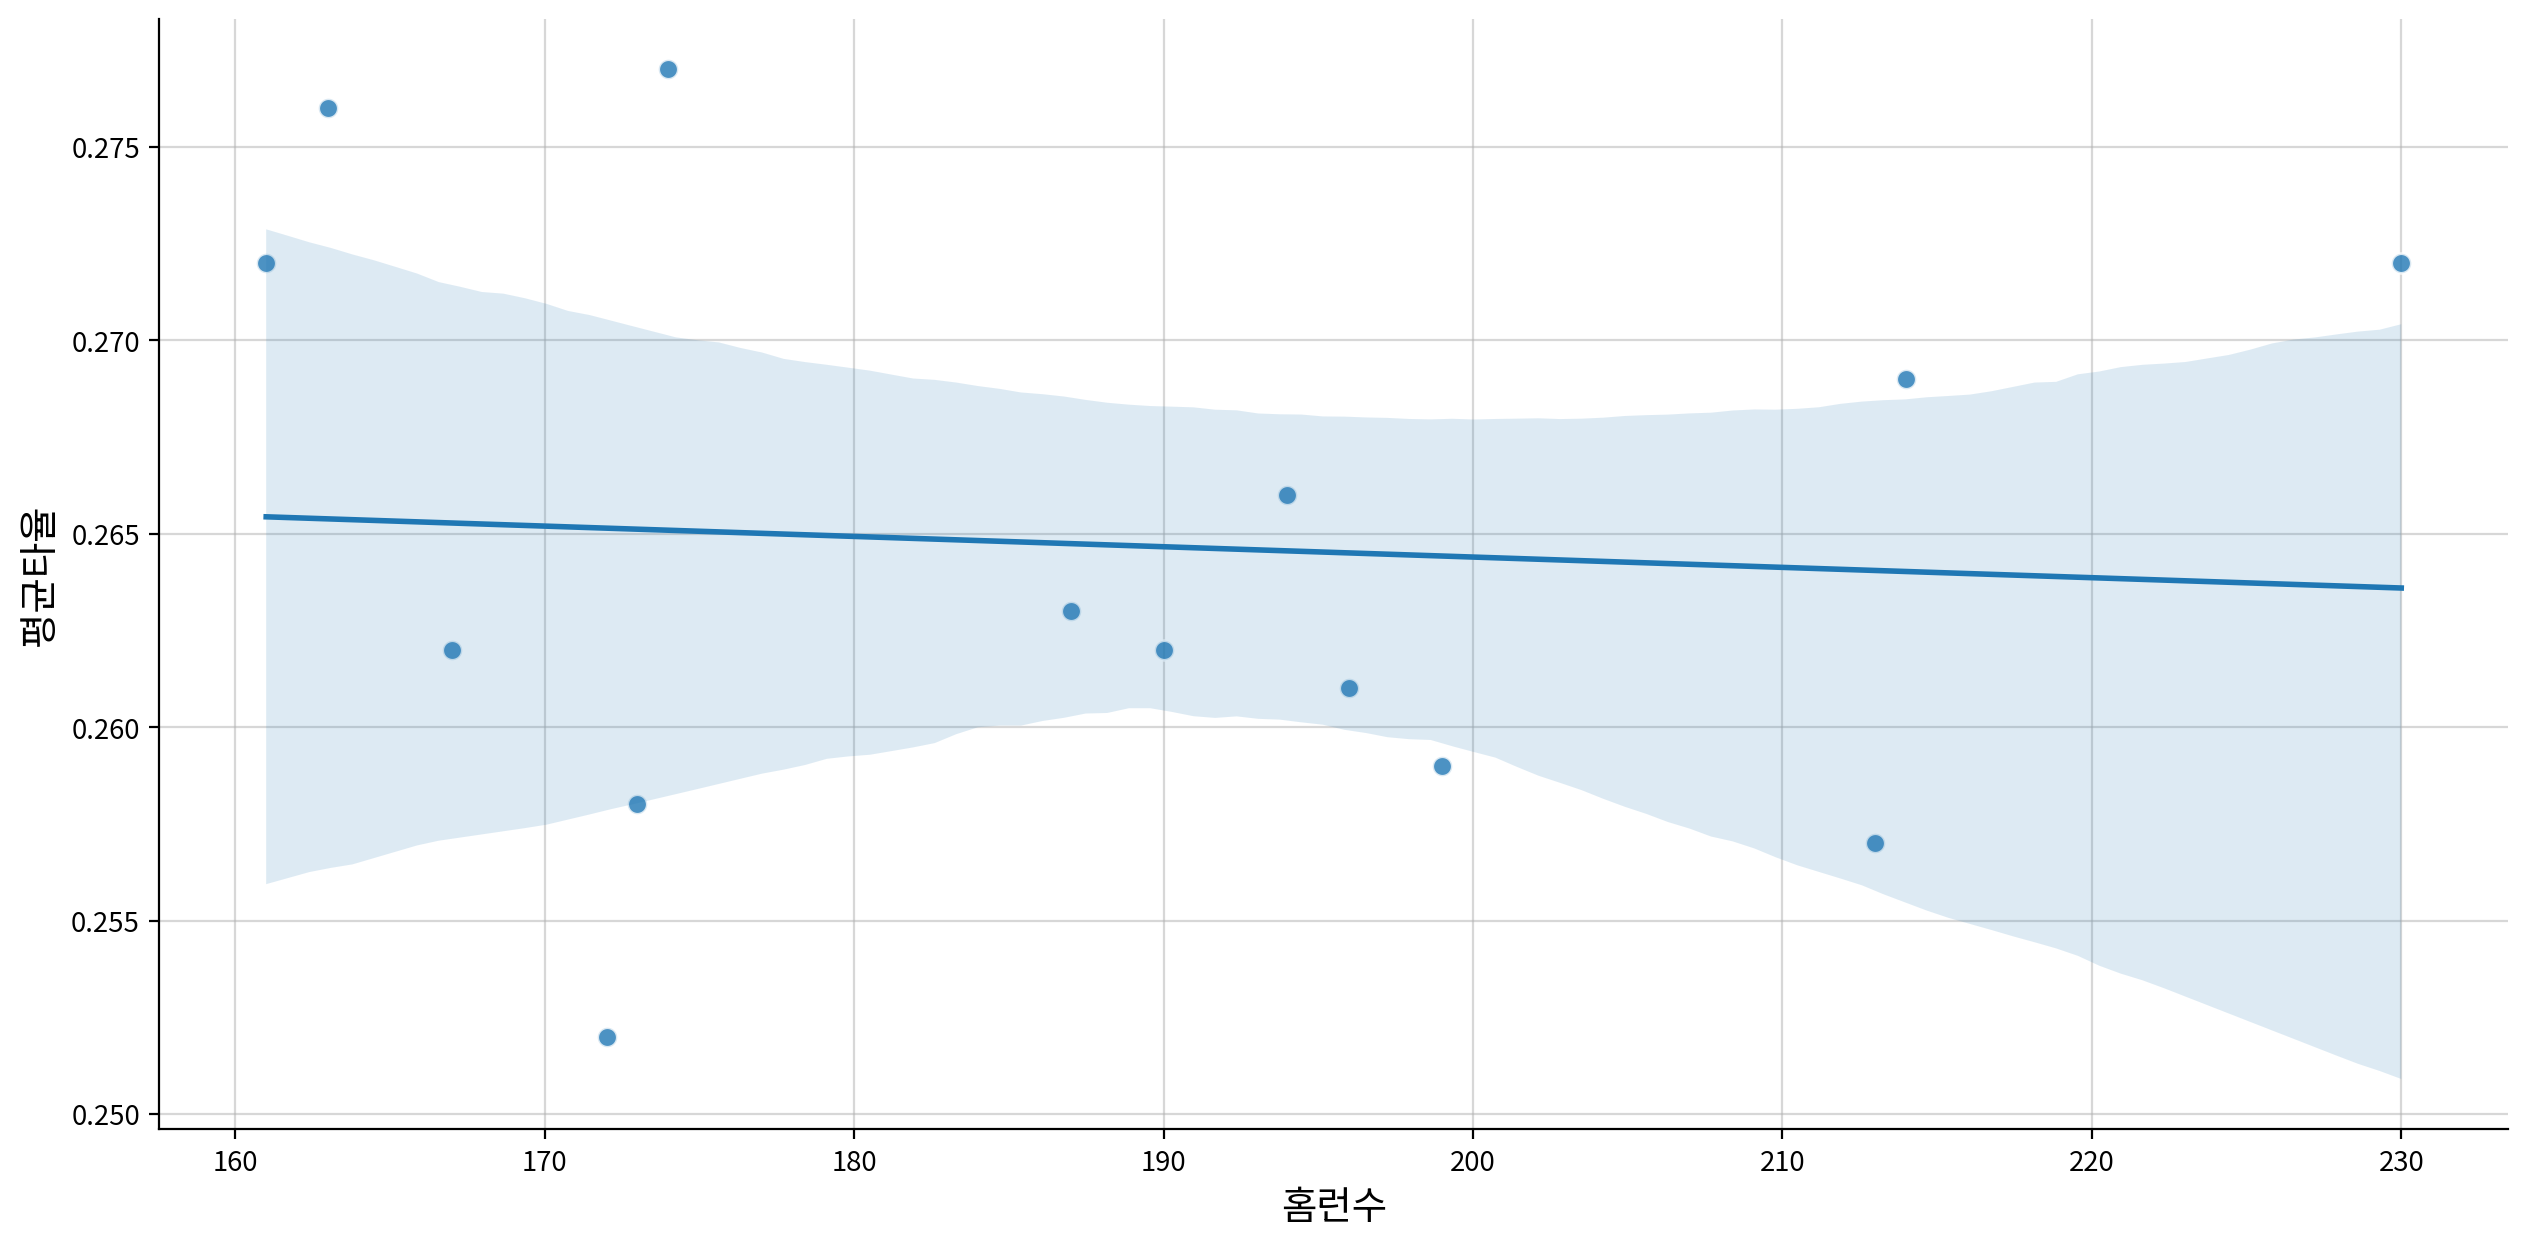

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
홈런수,평균타율,Pearson,-0.075,0.800,Weak,False,True,True,True,False,False


In [12]:
my_stats.correlation(df1, '홈런수', '평균타율')

- 상관관계가 거의 없음 - 피어슨 계수 -0.075(strength: Weak)로 0에 매우 가까움. 산점도에서도 점들이 특정 방향으로 모이지 않고 넓게 흩어져 있어 홈런수와 평균타율 간 뚜렷한 패턴이 보이지 않음
- 통계적으로 유의하지 않음 - p-value 0.800(>0.05), significant=False. 이 상관관계는 우연에 의한 변동으로 볼 수 있음
- 피어슨 사용은 가능하나 해석에 주의가 필요 - 정규성, 왜도 조건은 충족되지만 산점도에서 선형 패턴이 거의 보이지 않음. 따라서 피어슨 결과는 해석시 주의가 필요하며 필요 시 스피어만 계수와 같이 사용하는게 적절할 수 있음
- 홈런수로 평균타율을 설명하기 어려움 - 추세선이 거의 평평하고 신뢰구간도 넓어, 홈런수가 많다고 평균타율이 높거나 낮아진다고 보기 어려움

#### 문제 2. 원료의 품질특성과 제품의 특성의 상관관계를 구하라

In [13]:
df2 = load_data('product')
df2.head()

📚 어떤 원료의 품질특성(x)과 이 원료를 사용하여 만든 제품의 특성(y)에 관한 조사결과 (출처: 방송통신대학교 통계학 개론)


,x,y
0,36,29
1,40,32
2,34,29
3,44,40
4,33,31


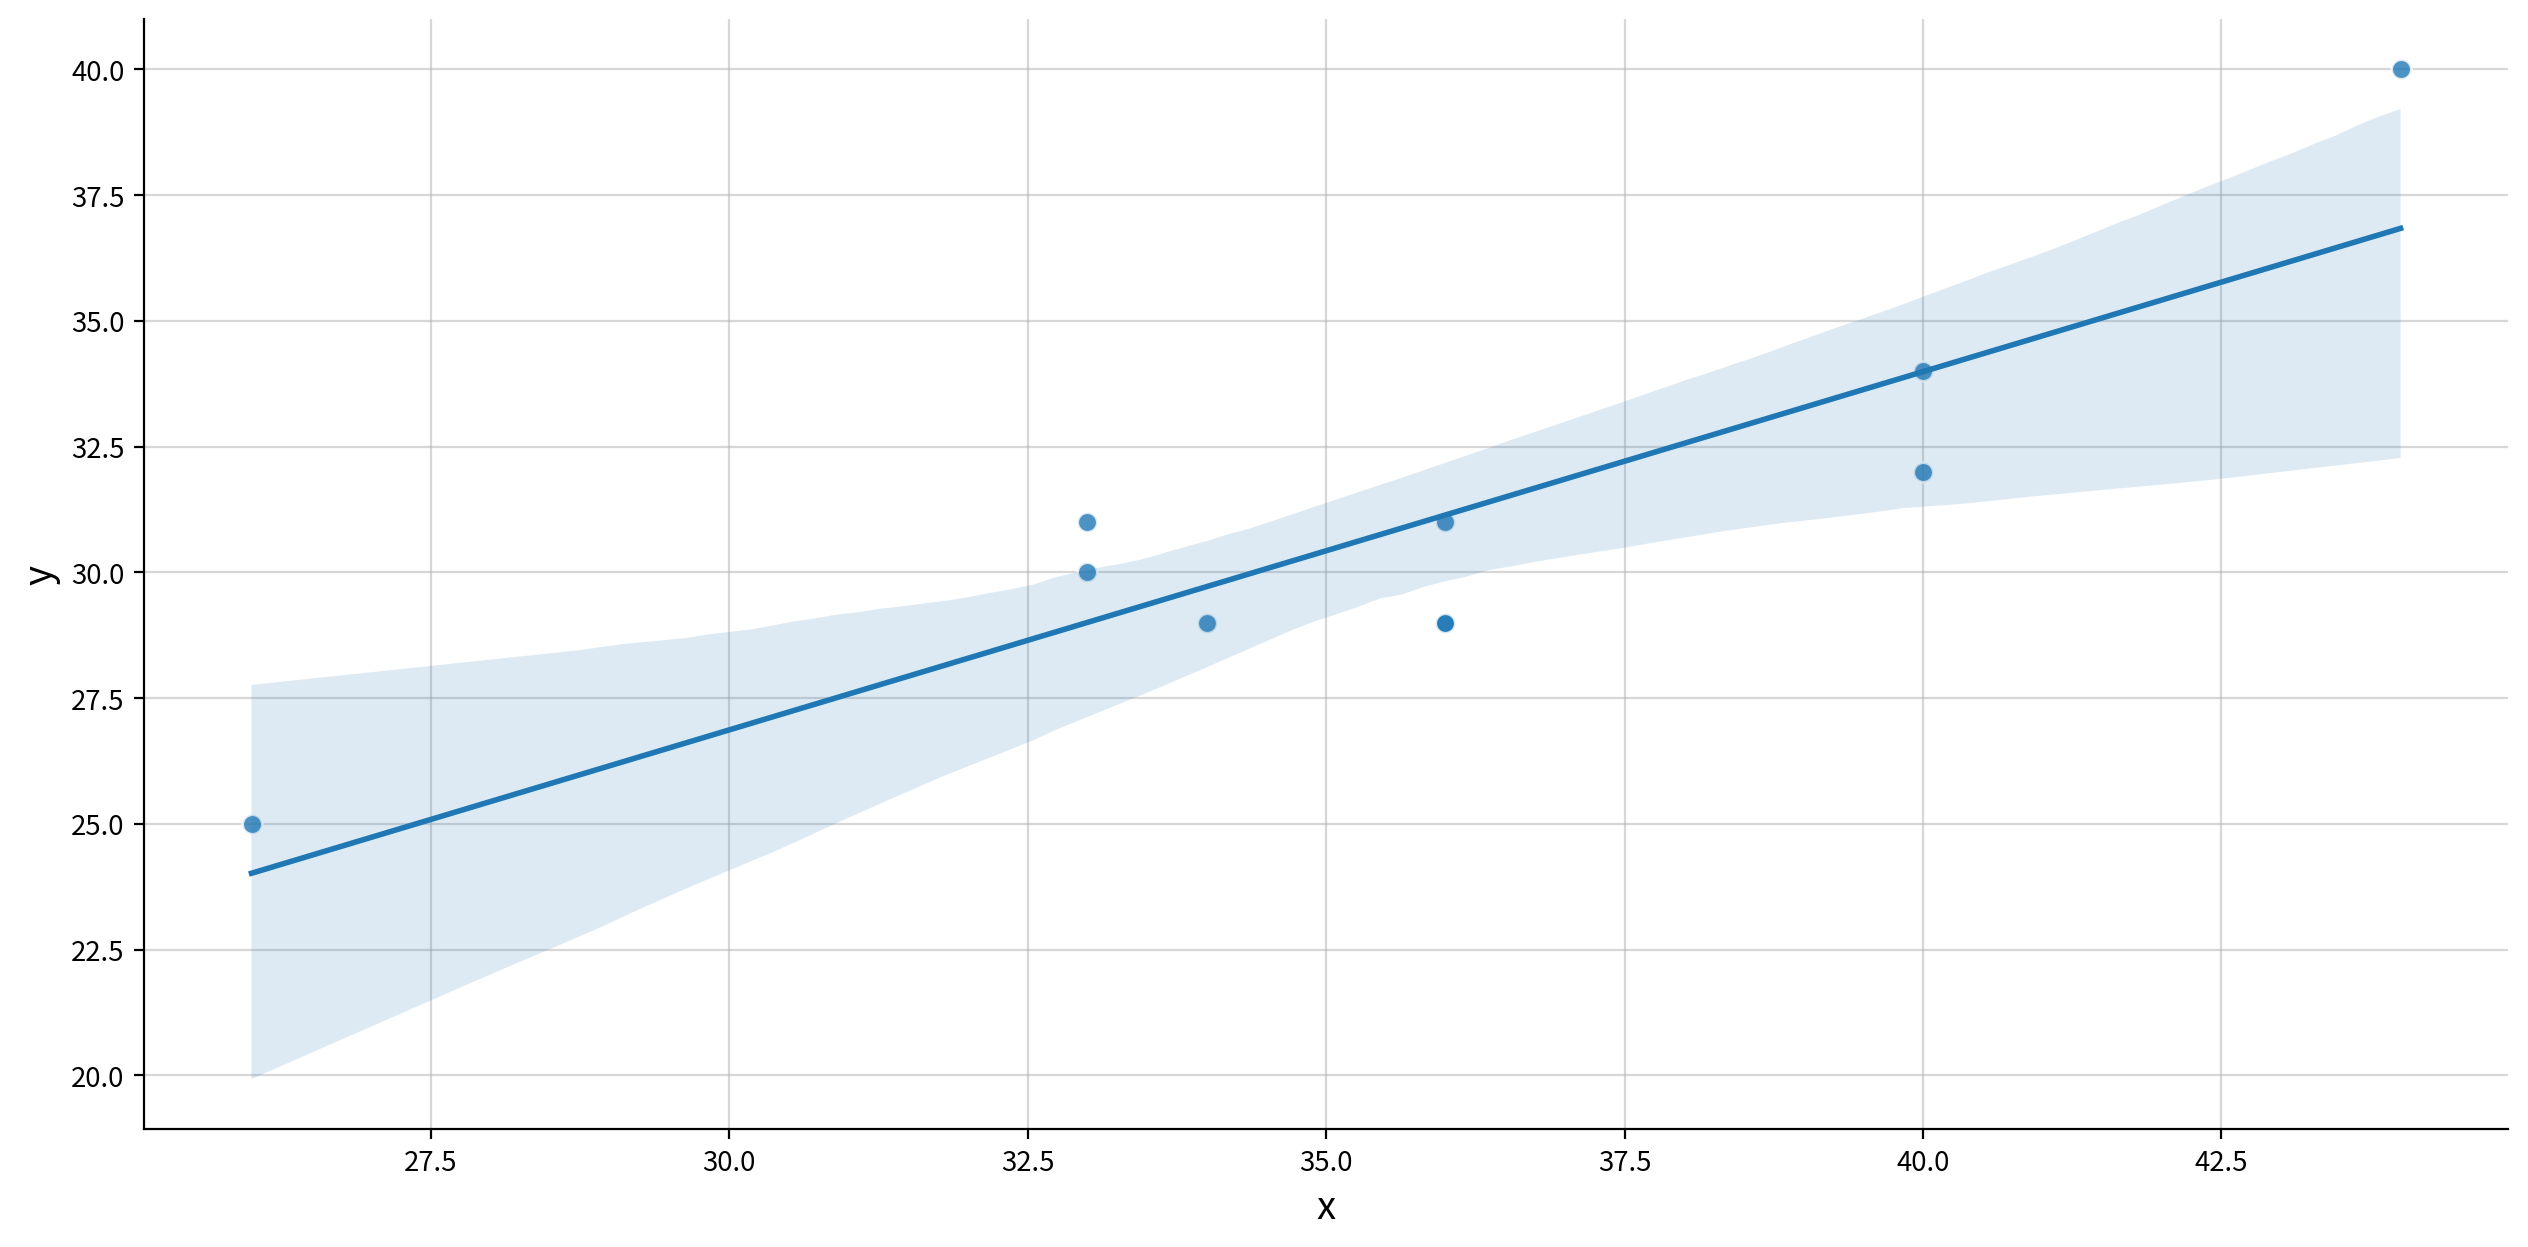

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
x,y,Spearman,0.737,0.015,Strong,True,True,False,True,False,True


In [14]:
my_stats.correlation(df2, 'x', 'y')

- 강한 양의 상관관계 - 스피어만 계수 0.737(strength: Strong). x가 높을수록 y도 함께 높아지는 경향이 있음
- 통계적으로 유의함 - p-value 0.015(<0.05), significant=True. 이 상관관계는 우연으로 보기 어려움
- 스피어만 계수를 쓰는 것이 타당 - y의 정규성 미충족(normality_y=False)과 큰 왜도(high_skew=True)로 인해 피어슨 가정을 위반했으므로 스피어만 계수를 채택함

#### 문제 3. 학생들의 공부시간과 성적의 상관관계를 구하라

In [15]:
df3 = load_data('study_time')
df3.head()

📚 학생들에 대한 공부 시간과 성적 데이터 (출처: 방송통신대학교 통계학 개론)


,공부시간,성적
0,2,65
1,4,85
2,3,75
3,5,90
4,6,95


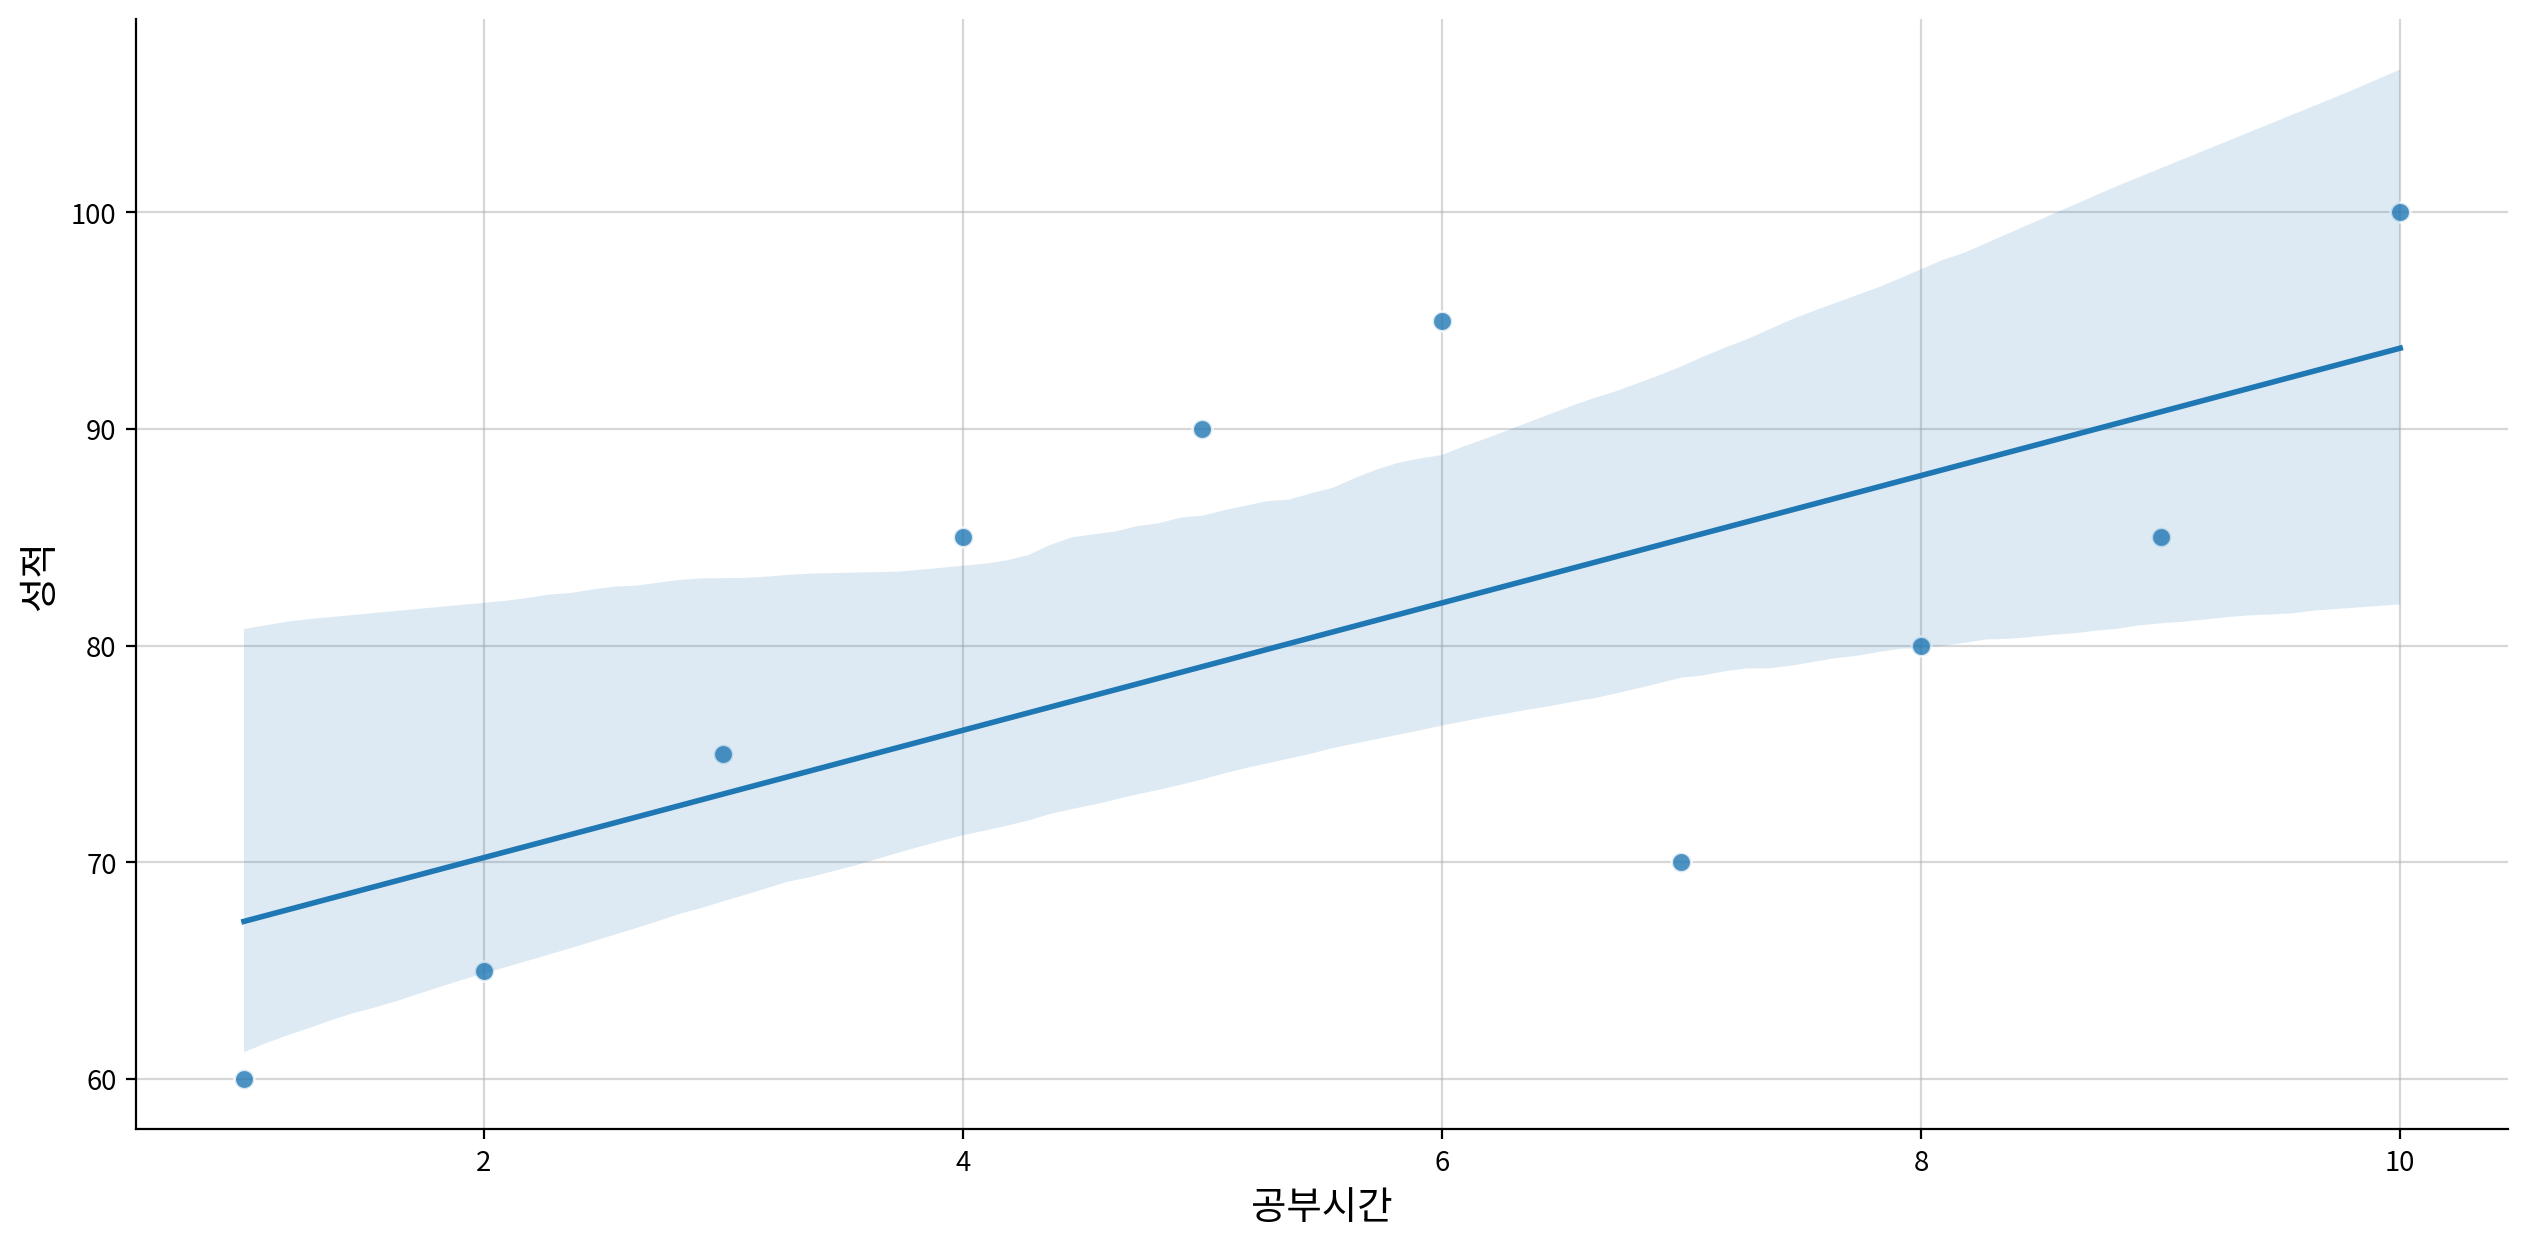

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
공부시간,성적,Pearson,0.684,0.029,Moderate,True,True,True,True,False,False


In [16]:
my_stats.correlation(df3, '공부시간', '성적')

- 중간정도의 양의 상관관계 - 피어슨 계수 0.684(strength: Moderate). 공부시간이 많을수록 성적도 함께 높아지는 경향이 있음
- 통계적으로 유의함 - p-value는 0.029(<0.05), significant=True. 이 상관관계는 우연으로 보기 어려움
- 피어슨 계수를 쓰는 것이 타당 - 정규성(공부시간, 성적 모두 True), 선형성(True)을 충족하고, 영향점(influential_outlier=False), 큰 왜도(high_skew=False)도 없어 스피어만이 아닌 피어슨이 적절한 상황
- 모든 가정을 만족 -> 결과 신뢰 가능 - 정규성/선형성/이상치 영향 점검을 모두 통과했으므로 해석에 무리가 없음
- 다만 '강한' 관계는 아님 - Moderate 수준(0.684)이므로 공부시간 외에 성적에 영향을 주는 다른 변수도 존재할 수 있음